In [1]:
%load_ext autoreload
%autoreload 2

from folde.util import load_checkpointed_model_eval, convert_compaign_result_collection_to_df, DMS_SHORTNAMES

results = load_checkpointed_model_eval(
    'notebooks/jacob/model_evals/',
    '250711-folde-testset-wCL',
    []
)
mutant_df, round_metrics_df = convert_compaign_result_collection_to_df(results)

Loading results for DMSs: {'P53_HUMAN_Giacomelli_2018_Null_Nutlin', 'AMIE_PSEAE_Wrenbeck_2017', 'ADRB2_HUMAN_Jones_2020', 'MET_HUMAN_Estevam_2023', 'PTEN_HUMAN_Mighell_2018', 'KKA2_KLEPN_Melnikov_2014', 'PPARG_HUMAN_Majithia_2016', 'LGK_LIPST_Klesmith_2015', 'KCNJ2_MOUSE_Coyote-Maestas_2022_function', 'MTHR_HUMAN_Weile_2021', 'MK01_HUMAN_Brenan_2016', 'S22A1_HUMAN_Yee_2023_activity', 'SC6A4_HUMAN_Young_2021', 'CAS9_STRP1_Spencer_2017_positive', 'P53_HUMAN_Giacomelli_2018_WT_Nutlin'}


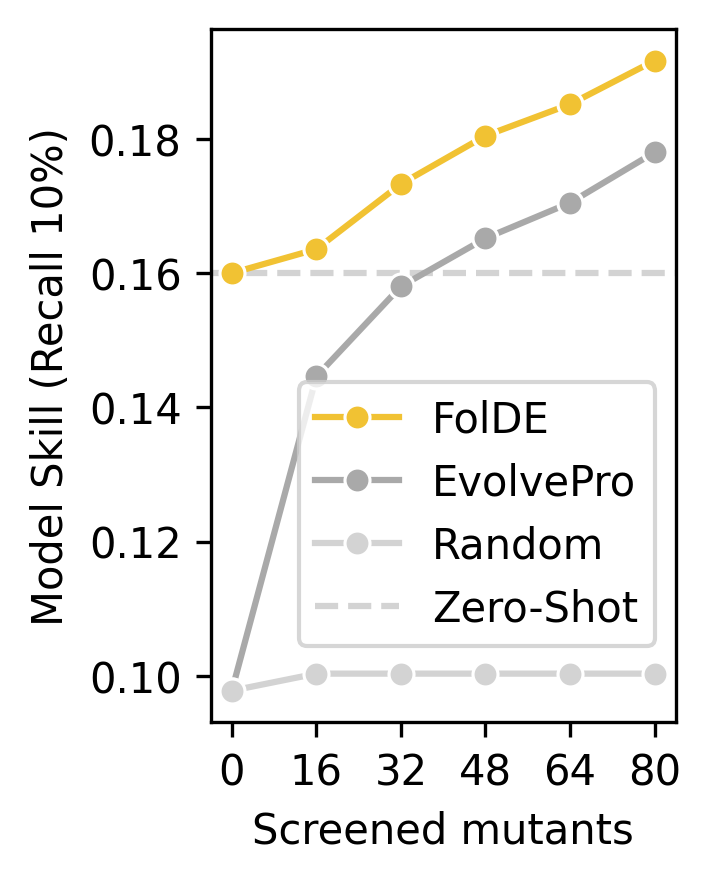

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

plot_df = round_metrics_df.copy()

METRIC = 'held_out_10pct_recall'
CONFIGS_TO_PLOT = ['FolDE', 'EvolvePro', 'Random']

plot_df['Screened mutants'] = plot_df.round_num * 16 - 16
plot_df['config_name'] = plot_df.config_name.apply(lambda x: {
    'FolDE-base': 'FolDE',
    'FolDE-random': 'Random',
    'FolDE-Random-RandomForestCtrl': 'EvolvePro'
}.get(x, x))

plt.subplots(figsize=(2, 3), dpi=300)
plt.axhline(plot_df[
        (plot_df.config_name == 'FolDE') &
        (plot_df.round_num == 1)
    ][METRIC].mean(),
    color='lightgrey',
    linestyle='--',
    label='Zero-Shot')
ax = sns.lineplot(
    data=plot_df[(plot_df.round_num <= 6) & (
        plot_df.config_name.isin(CONFIGS_TO_PLOT))],
    # y='held_out_activity_spearman',
    # y='held_out_10pct_recall',
    y=METRIC,
    # y='held_out_activity_spearman',
    x='Screened mutants',
    hue='config_name',
    errorbar=None,
    marker='o',
    hue_order=CONFIGS_TO_PLOT,
    palette={'FolDE': '#F1C233', 'EvolvePro': 'darkgrey', 'Random': 'lightgrey'}
    # style='config_name',
    # errorbar=None
)
plt.ylabel('Model Skill (Recall 10%)')
plt.xticks([0, 16, 32, 48, 64, 80])


# reorder legend
handles, labels = ax.get_legend_handles_labels()
order = list(range(1, len(handles))) + [0]
# Move legend to bottom right
ax.legend(
    [handles[i] for i in order],
    [labels[i] for i in order],
    loc='right',
    bbox_to_anchor=(1.0, 0.3)
)

# plt.ylim(0, 0.1)
# round_metrics_df